# IEEE 6-Bus 25kV System in Pandapower

The figure bellow shows a 25 kV IEEE 6-bus system which can represent a distribution system. The parameters of this system are given in Table I & II. Assuming a 100MVA base, do the following:
1. Create the pandapower model of the network.
2. Run a power flow and show voltages in the nodes, current through the lines, power in the nodes (injecting/compsuming).
3. If a 5.0 MW solar plant is planned to be connected at one of the different buses of the system (i.e., bus 2-6), what would be the power losses in the system? Draw snapshot of your results in one figure comparing: base case (no solar plant) versus other cases. Based on your results, what would be the best location for the solar plant to achieve minimum real power losses? how the new solar plant would affect the voltage profile? Assume the solar plant operates at unity power factor.


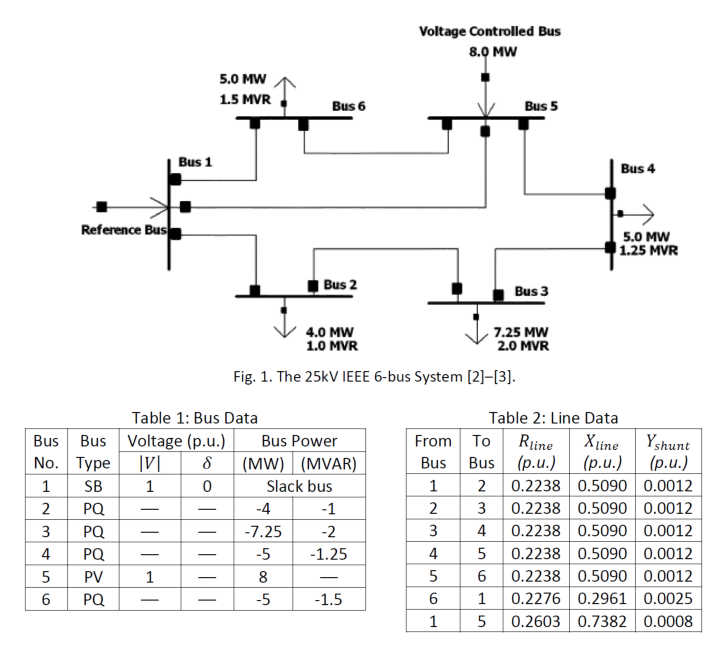

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('fig/image.png')
plt.figure(figsize=(6, 4), dpi=200)
plt.axis('off')
plt.imshow(img)
plt.show()

### Import Pandapower

In [4]:
import pandapower as pp
import pandas as pd
import math

### Create Empty Network

In [5]:
net = pp.create_empty_network() #create an empty network
net.sn_mva = 100.0  # Set base power to 100 MVA

### Buses

We create 6 buses at 25kV voltage level:

In [6]:
bus1 = pp.create_bus(net, name="Bus 1 (Slack)", vn_kv=25, type="b")
bus2 = pp.create_bus(net, name="Bus 2 (PQ)", vn_kv=25, type="b")
bus3 = pp.create_bus(net, name="Bus 3 (PQ)", vn_kv=25, type="b")
bus4 = pp.create_bus(net, name="Bus 4 (PQ)", vn_kv=25, type="b")
bus5 = pp.create_bus(net, name="Bus 5 (PV)", vn_kv=25, type="b")
bus6 = pp.create_bus(net, name="Bus 6 (PQ)", vn_kv=25, type="b")

#display
net.bus

,name,vn_kv,type,zone,in_service,geo
0,Bus 1 (Slack),25.0,b,None,True,None
1,Bus 2 (PQ),25.0,b,None,True,None
2,Bus 3 (PQ),25.0,b,None,True,None
3,Bus 4 (PQ),25.0,b,None,True,None
4,Bus 5 (PV),25.0,b,None,True,None
5,Bus 6 (PQ),25.0,b,None,True,None


### External Grid (Slack Bus)

We create an external grid connection at Bus 1 which serves as the slack bus:

In [7]:
pp.create_ext_grid(net, bus1, vm_pu=1.0, va_degree=0.0)

#display
net.ext_grid

,name,bus,vm_pu,va_degree,slack_weight,in_service,controllable
0,None,0,1.0,0.0,1.0,True,False


### Lines

As the data is given in p.u. values, no additional information about the lines is given and the line information to pandapower require the electrical parameters to be given per km along with the length of the line. A length for all lines is assumed 1km and a maximum capacity of 500 A. The frequency is considered 50 Hz. 

First, we create standard line types. 

In [8]:
# Create standard types for our lines
# Base impedance for 25kV: Z_base = V_base^2 / S_base = (25^2) / 100 = 6.25 ohms
z_base = 25**2 / 100

# Base admittance for capacitance conversion
y_base = 1 / z_base  # Siemens

# For shunt capacitance: c_nf_per_km = (Y_shunt_pu * y_base) / (2 * pi * f) * 1e9
# Where f = 50 Hz 
f = 50  # Hz
omega = 2 * math.pi * f

# Define our custom standard types with proper shunt admittance
custom_std_types = {
    "IEEE_Line_Type1": {
        "r_ohm_per_km": 0.2238 * z_base,
        "x_ohm_per_km": 0.5090 * z_base,
        "c_nf_per_km": (0.0012 * y_base) / omega * 1e9,  # Convert Y_shunt to capacitance
        "max_i_ka": 0.5
    },
    "IEEE_Line_Type2": {
        "r_ohm_per_km": 0.2276 * z_base,
        "x_ohm_per_km": 0.2961 * z_base,
        "c_nf_per_km": (0.0025 * y_base) / omega * 1e9,  # Convert Y_shunt to capacitance
        "max_i_ka": 0.5
    },
    "IEEE_Line_Type3": {
        "r_ohm_per_km": 0.2603 * z_base,
        "x_ohm_per_km": 0.7382 * z_base,
        "c_nf_per_km": (0.0008 * y_base) / omega * 1e9,  # Convert Y_shunt to capacitance
        "max_i_ka": 0.5
    }
}

# NOTICE that y_shunt_pu is divided by 2 (internally by pandapower) when creating the pi-model of the line. Then the admittance matrix is built accordingly.

# Add custom standard types to the network
net.std_types["line"].update(custom_std_types)

print("Custom standard types created with shunt admittance:")
for name, params in custom_std_types.items():
    print(f"{name}: R={params['r_ohm_per_km']:.4f} Ω/km, X={params['x_ohm_per_km']:.4f} Ω/km, C={params['c_nf_per_km']:.1f} nF/km")

Custom standard types created with shunt admittance:
IEEE_Line_Type1: R=1.3987 Ω/km, X=3.1812 Ω/km, C=611.2 nF/km
IEEE_Line_Type2: R=1.4225 Ω/km, X=1.8506 Ω/km, C=1273.2 nF/km
IEEE_Line_Type3: R=1.6269 Ω/km, X=4.6137 Ω/km, C=407.4 nF/km


Then, we create the transmission lines using the standard types we defined:

In [9]:
# Create lines using standard types
# Lines 1-2, 2-3, 3-4, 4-5, 5-6 use Type1
pp.create_line(net, bus1, bus2, length_km=1, std_type="IEEE_Line_Type1", name="Line 1-2")
pp.create_line(net, bus2, bus3, length_km=1, std_type="IEEE_Line_Type1", name="Line 2-3")
pp.create_line(net, bus3, bus4, length_km=1, std_type="IEEE_Line_Type1", name="Line 3-4")
pp.create_line(net, bus4, bus5, length_km=1, std_type="IEEE_Line_Type1", name="Line 4-5")
pp.create_line(net, bus5, bus6, length_km=1, std_type="IEEE_Line_Type1", name="Line 5-6")

# Line 6-1 uses Type2
pp.create_line(net, bus6, bus1, length_km=1, std_type="IEEE_Line_Type2", name="Line 6-1")

# Line 1-5 uses Type3
pp.create_line(net, bus1, bus5, length_km=1, std_type="IEEE_Line_Type3", name="Line 1-5")

#display
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,geo
0,Line 1-2,IEEE_Line_Type1,0,1,1.0,1.398750,3.181250,611.154981,0.0,0.5,1.0,1,NaN,True,NaN
1,Line 2-3,IEEE_Line_Type1,1,2,1.0,1.398750,3.181250,611.154981,0.0,0.5,1.0,1,NaN,True,NaN
2,Line 3-4,IEEE_Line_Type1,2,3,1.0,1.398750,3.181250,611.154981,0.0,0.5,1.0,1,NaN,True,NaN
3,Line 4-5,IEEE_Line_Type1,3,4,1.0,1.398750,3.181250,611.154981,0.0,0.5,1.0,1,NaN,True,NaN
4,Line 5-6,IEEE_Line_Type1,4,5,1.0,1.398750,3.181250,611.154981,0.0,0.5,1.0,1,NaN,True,NaN
5,Line 6-1,IEEE_Line_Type2,5,0,1.0,1.422500,1.850625,1273.239545,0.0,0.5,1.0,1,NaN,True,NaN
6,Line 1-5,IEEE_Line_Type3,0,4,1.0,1.626875,4.613750,407.436654,0.0,0.5,1.0,1,NaN,True,NaN


### Loads

We create the loads at PQ buses:

In [10]:
# Bus 2: 4 MW, 1 MVAR
pp.create_load(net, bus2, p_mw=4, q_mvar=1, name="Load Bus 2")

# Bus 3: 7.25 MW, 2 MVAR
pp.create_load(net, bus3, p_mw=7.25, q_mvar=2, name="Load Bus 3")

# Bus 4: 5 MW, 1.25 MVAR
pp.create_load(net, bus4, p_mw=5, q_mvar=1.25, name="Load Bus 4")

# Bus 6: 5 MW, 1.5 MVAR
pp.create_load(net, bus6, p_mw=5, q_mvar=1.5, name="Load Bus 6")

# Display
net.load

,name,bus,p_mw,q_mvar,const_z_percent,const_i_percent,sn_mva,scaling,in_service,type
0,Load Bus 2,1,4.00,1.00,0.0,0.0,NaN,1.0,True,wye
1,Load Bus 3,2,7.25,2.00,0.0,0.0,NaN,1.0,True,wye
2,Load Bus 4,3,5.00,1.25,0.0,0.0,NaN,1.0,True,wye
3,Load Bus 6,5,5.00,1.50,0.0,0.0,NaN,1.0,True,wye


### Generator

We create the generator at Bus 5:

In [11]:
# Bus 5: 8 MW generation, voltage controlled at 1.0 p.u.
pp.create_gen(net, bus5, p_mw=8, vm_pu=1.0, min_q_mvar=-10, max_q_mvar=10, name="Generator Bus 5")

# Display
net.gen

,name,bus,p_mw,vm_pu,sn_mva,min_q_mvar,max_q_mvar,scaling,slack,controllable,id_q_capability_curve_characteristic,reactive_capability_curve,curve_style,in_service,slack_weight,type
0,Generator Bus 5,4,8.0,1.0,NaN,-10.0,10.0,1.0,False,True,<NA>,False,NaN,True,0.0,None


### Running Power Flow

In [20]:
pp.run.runpp(net, algorithm="nr", max_iteration=50, tol=1e-6)  
print(f"Converged: {net.converged}")
print(f"Number of iterations: {net._ppc['iterations']}")    
print("Network Summary:")
print("=" * 50)
print(f"Base Power: {net.sn_mva} MVA")
print(f"Base Voltage: 25 kV")
print(f"Number of Buses: {len(net.bus)}")
print(f"Number of Lines: {len(net.line)}")
print(f"Number of Loads: {len(net.load)}")
print(f"Number of Generators: {len(net.gen)}")

Converged: True
Number of iterations: 3
Network Summary:
Base Power: 100.0 MVA
Base Voltage: 25 kV
Number of Buses: 6
Number of Lines: 7
Number of Loads: 4
Number of Generators: 1


### Results

In [13]:
print("Bus Results:")
net.res_bus['name'] = net.bus['name']
print(net.res_bus[['name', 'vm_pu', 'va_degree', 'p_mw', 'q_mvar']])


Bus Results:
            name     vm_pu  va_degree       p_mw    q_mvar
0  Bus 1 (Slack)  1.000000   0.000000 -13.705472 -1.578843
1     Bus 2 (PQ)  0.970601  -2.255134   4.000000  1.000000
2     Bus 3 (PQ)  0.956068  -3.478836   7.250000  2.000000
3     Bus 4 (PQ)  0.968885  -2.683722   5.000000  1.250000
4     Bus 5 (PV)  1.000000  -0.568601  -8.000000 -4.271299
5     Bus 6 (PQ)  0.990823  -0.688635   5.000000  1.500000


In [14]:
# Active and reactive power losses
p_losses = net.res_bus['p_mw'].sum()
q_losses = net.res_bus['q_mvar'].sum()
print(f"\nTotal Active Power Losses: {p_losses:.4f} MW")
print(f"Total Reactive Power Losses: {q_losses:.4f} MVAR")


Total Active Power Losses: -0.4555 MW
Total Reactive Power Losses: -0.1001 MVAR


### Voltage profile

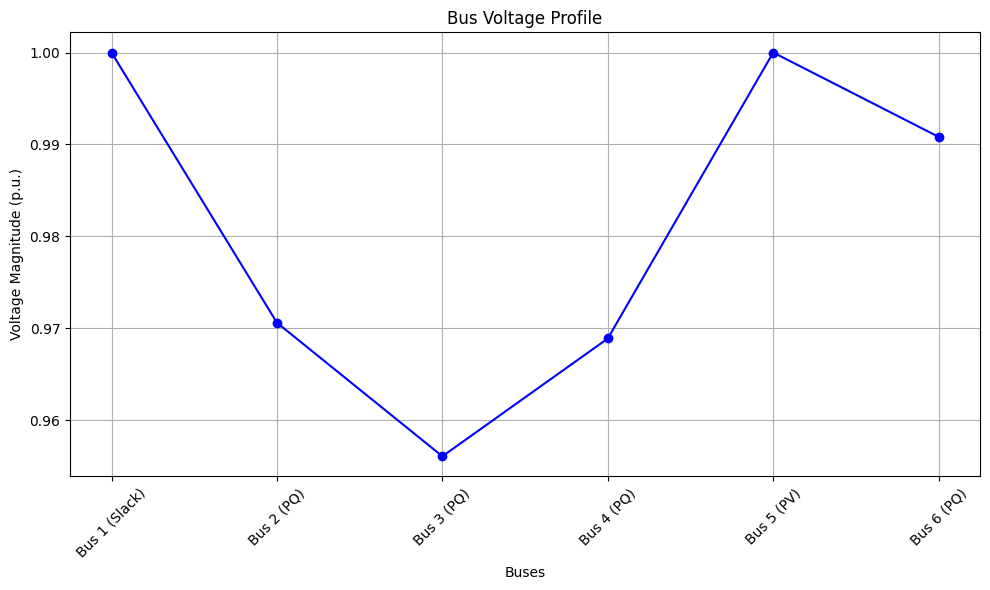

In [15]:
# Plot voltage profile
plt.figure(figsize=(10, 6)) 
plt.plot(net.res_bus.index, net.res_bus['vm_pu'], marker='o', linestyle='-', color='b')
plt.xticks(net.res_bus.index, net.bus['name'], rotation=45) 
plt.title("Bus Voltage Profile")
plt.xlabel("Buses")
plt.ylabel("Voltage Magnitude (p.u.)")  
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
print("\nLine Loading:")
net.res_line['name'] = net.line['name']
print(net.res_line[['name', 'p_from_mw', 'q_from_mvar', 'i_from_ka', 'loading_percent']])



Line Loading:
       name  p_from_mw  q_from_mvar  i_from_ka  loading_percent
0  Line 1-2   8.470434     2.139284   0.201759        40.478637
1  Line 2-3   4.299037     0.865990   0.104344        20.975223
2  Line 3-4  -2.996890    -1.127097   0.077341        15.468152
3  Line 4-5  -8.021695    -2.322344   0.199054        39.810784
4  Line 5-6   1.006222     1.300994   0.037983         8.039757
5  Line 6-1  -4.000189    -0.094684   0.093262        18.653711
6  Line 1-5   1.197750    -0.455674   0.029595         5.918998


### Network Plot

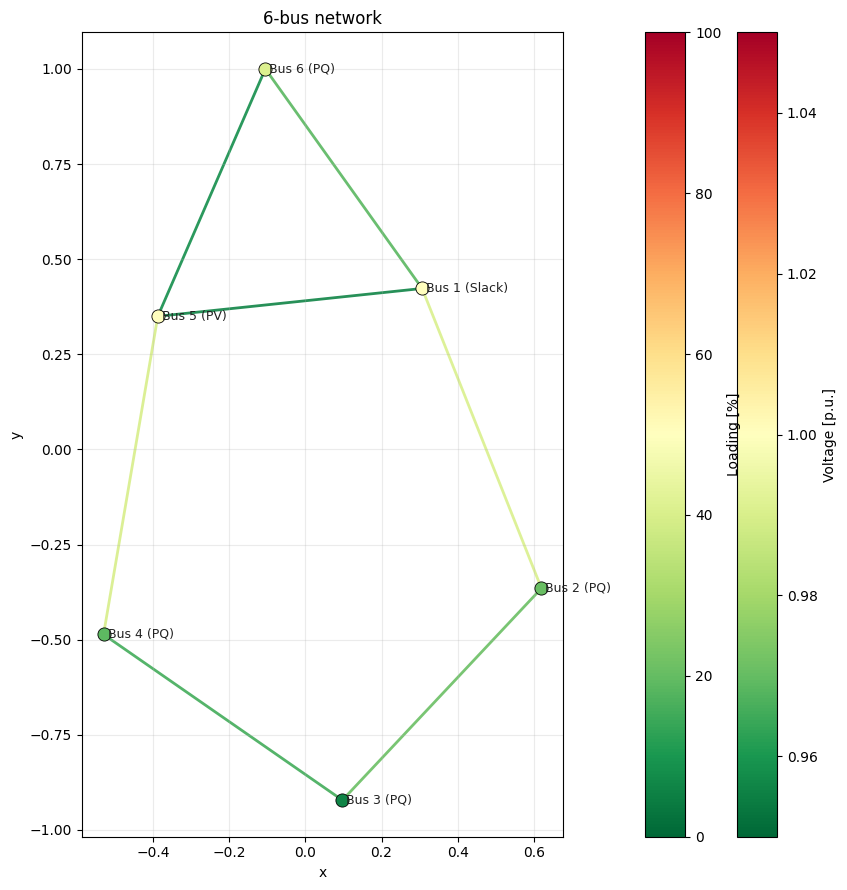

In [17]:
from importlib import reload
import pp_plot_network as ppn
reload(ppn)

ppn.plot_network_overview(
    net,
    vmin=0.95, vmax=1.05,
    line_min=0, line_max=100,
    annotate=True,
    show_switches=True,
    show_open_only=False,
    lv_max_kv=1.0, mv_max_kv=72.5,
    overload_threshold=100.0,
    voltage_warn=(0.95, 1.05),
    figsize=(12, 9),
    bus_size=90,
    title="6-bus network",
    savepath=None  # e.g., "my_network.png"
)

#### Admitance Matrix

Admittance Matrix Shape: (6, 6)
Admittance Matrix:
<Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 20 stored elements and shape (6, 6)>
  Coords	Values
  (0, 0)	(2.780534311001623-4.971878445755874j)
  (0, 1)	(-0.7238795909426943+1.6463570678723476j)
  (0, 4)	(-0.4248441064501014+1.2048402588607947j)
  (0, 5)	(-1.6318106136088275+2.122931119022732j)
  (1, 0)	(-0.7238795909426943+1.6463570678723476j)
  (1, 1)	(1.4477591818853885-3.2915141357446953j)
  (1, 2)	(-0.7238795909426943+1.6463570678723476j)
  (2, 1)	(-0.7238795909426943+1.6463570678723476j)
  (2, 2)	(1.4477591818853885-3.2915141357446953j)
  (2, 3)	(-0.7238795909426943+1.6463570678723476j)
  (3, 2)	(-0.7238795909426943+1.6463570678723476j)
  (3, 3)	(1.4477591818853885-3.2915141357446953j)
  (3, 4)	(-0.7238795909426943+1.6463570678723476j)
  (4, 0)	(-0.4248441064501014+1.2048402588607947j)
  (4, 3)	(-0.7238795909426943+1.6463570678723476j)
  (4, 4)	(1.87260328833549-4.49595439460549j)
  (4, 5)	(-0.72387959094269

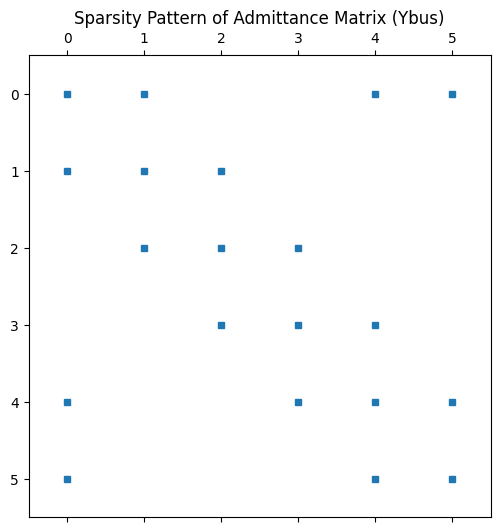

In [18]:
# The admittance matrix is available in the network's internal data after running power flow
Ybus = net._ppc["internal"]["Ybus"]
print("Admittance Matrix Shape:", Ybus.shape)
print("Admittance Matrix:")
print(Ybus)

# Represent sparcity of Ybus
plt.figure(figsize=(6, 6))
plt.spy(Ybus, markersize=5) 
plt.title("Sparsity Pattern of Admittance Matrix (Ybus)")
plt.show()

### Impact of 5 MW solar plant
1. Created a function to simulate adding a solar plant at a specific bus and solving the power flow.
2. Created a function to calculate total real power losses from line results.     
3. Simulated adding a 5 MW solar plant at each bus from 2 to 6, solved the power flow, and calculated total real power losses.
4. Compared the total real power losses for each case with the base case (no solar plant) and identified the bus location that resulted in the minimum losses. 
5. Analyzed the impact of the new solar plant on the voltage profile at each bus.

Power Losses Analysis:
  DG Location  Total Real Power Losses (MW)
0  Bus 2 (PQ)                      0.297886
1  Bus 3 (PQ)                      0.210096
2  Bus 4 (PQ)                      0.280056
3  Bus 5 (PV)                      0.443442
4  Bus 6 (PQ)                      0.408518
5   Base Case                      0.455474


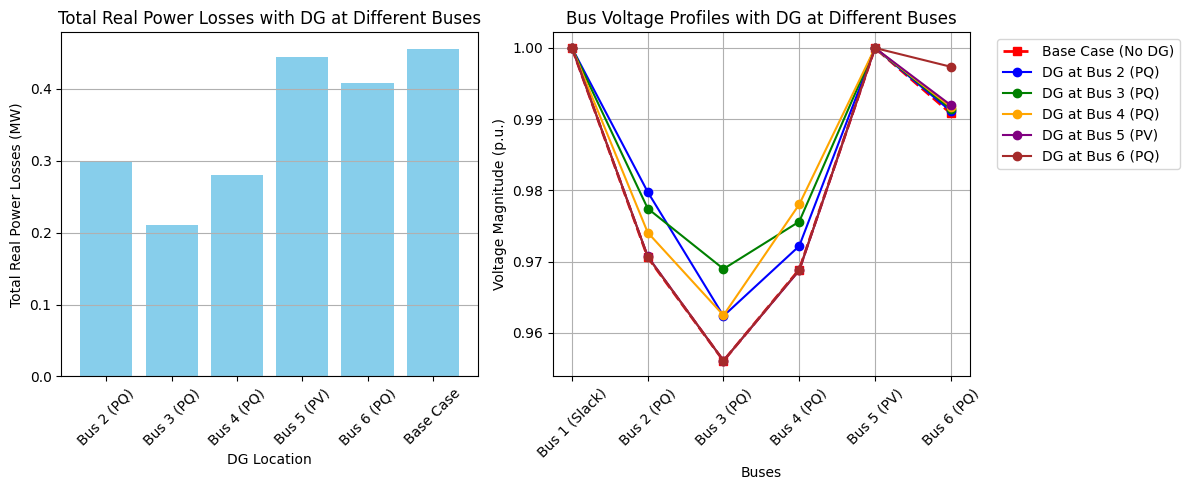

In [19]:
import copy

def simulate_dg_at_bus(net, bus_id, dg_power_mw=5.0):
    """
    Simulate adding a DG at a specific bus and return the network copy with results
    
    Parameters:
    - net: Original pandapower network
    - bus_id: Bus index where DG will be added
    - dg_power_mw: DG power in MW
    
    Returns:
    - net_copy: Network copy with DG added and power flow solved
    """
    net_copy = copy.deepcopy(net)
    pp.create_sgen(net_copy, bus_id, p_mw=dg_power_mw, 
                   name=f"DG at Bus {net.bus.at[bus_id, 'name']}")
    pp.runpp(net_copy)
    return net_copy

def calculate_total_losses(net):
    """Calculate total real power losses from line results"""
    return net.res_line['p_from_mw'].sum() + net.res_line['p_to_mw'].sum()

# Define buses to test DG placement
test_buses = [bus2, bus3, bus4, bus5, bus6]
dg_power = 5.0  # MW

# Run simulations for all buses and store results
simulation_results = {}
losses = {}

# Simulate DG at each bus
for bus in test_buses:
    net_with_dg = simulate_dg_at_bus(net, bus, dg_power)
    simulation_results[bus] = net_with_dg
    
    # Calculate losses for this configuration
    total_losses = calculate_total_losses(net_with_dg)
    bus_name = net.bus.at[bus, 'name']
    losses[bus_name] = total_losses

# Calculate base case losses (no DG)
pp.runpp(net)
base_case_losses = calculate_total_losses(net)
losses['Base Case'] = base_case_losses

# Display losses in a table
losses_df = pd.DataFrame(list(losses.items()), columns=['DG Location', 'Total Real Power Losses (MW)'])
print("Power Losses Analysis:")
print(losses_df)

# Plot losses comparison
plt.figure(figsize=(12, 5))

# Subplot 1: Bar chart of losses
plt.subplot(1, 2, 1)
plt.bar(losses.keys(), losses.values(), color='skyblue')
plt.title("Total Real Power Losses with DG at Different Buses")
plt.xlabel("DG Location")
plt.ylabel("Total Real Power Losses (MW)")
plt.xticks(rotation=45)
plt.grid(axis='y')

# Subplot 2: Voltage profiles
plt.subplot(1, 2, 2)

# Plot base case voltage profile
plt.plot(net.res_bus.index, net.res_bus['vm_pu'], 
         marker='s', linestyle='--', linewidth=2, 
         label='Base Case (No DG)', color='red')

# Plot voltage profiles for each DG location
colors = ['blue', 'green', 'orange', 'purple', 'brown']
for i, bus in enumerate(test_buses):
    net_with_dg = simulation_results[bus]
    bus_name = net.bus.at[bus, 'name']
    plt.plot(net_with_dg.res_bus.index, net_with_dg.res_bus['vm_pu'], 
             marker='o', linestyle='-', 
             label=f'DG at {bus_name}', color=colors[i % len(colors)])

plt.xticks(net.res_bus.index, net.bus['name'], rotation=45)
plt.title("Bus Voltage Profiles with DG at Different Buses")
plt.xlabel("Buses")
plt.ylabel("Voltage Magnitude (p.u.)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()